In [2]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/hdb_resale_cleaned.csv")

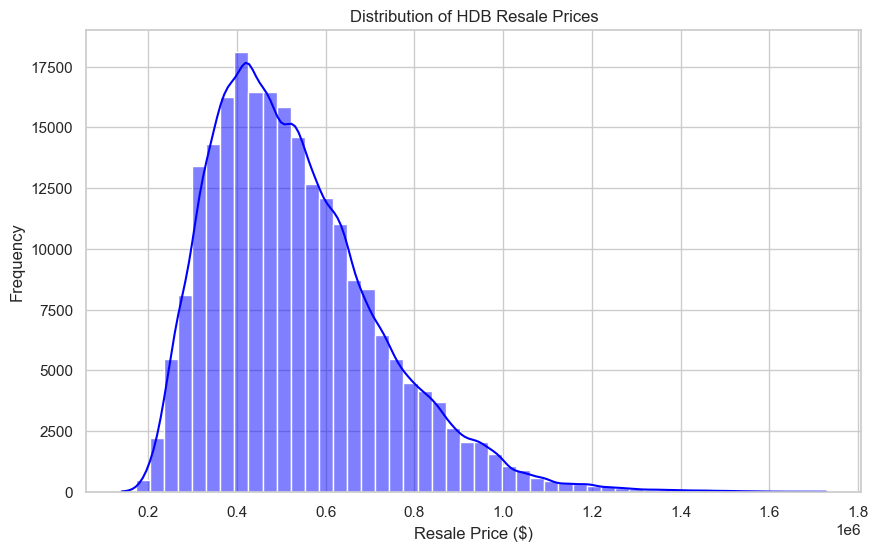

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['resale_price'], bins=50, kde=True, color='blue')
plt.title('Distribution of HDB Resale Prices')
plt.xlabel('Resale Price ($)')
plt.ylabel('Frequency')
plt.show()


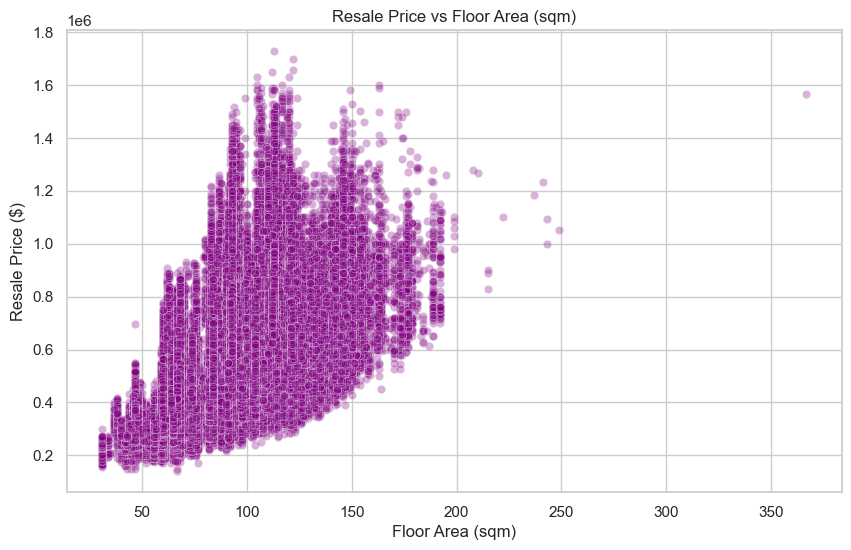

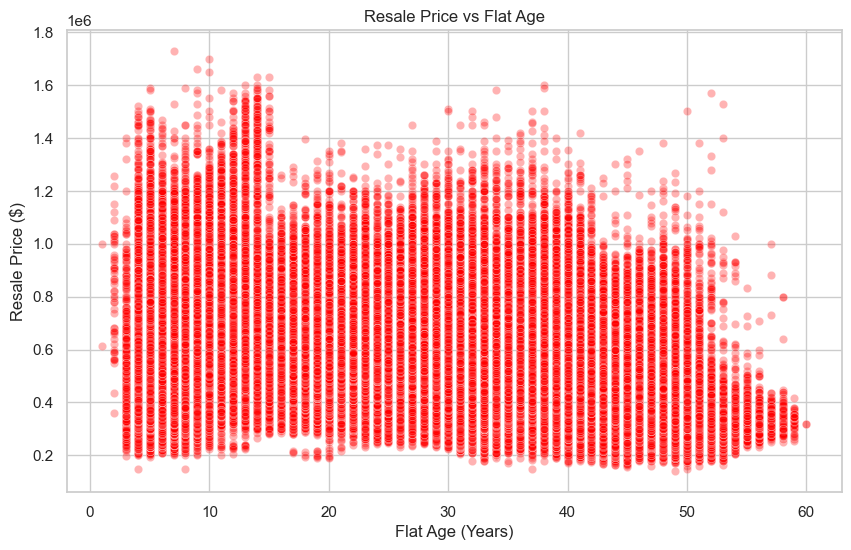

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='floor_area_sqm', y='resale_price', data=df, alpha=0.3, color='purple')
plt.title('Resale Price vs Floor Area (sqm)')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price ($)')
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='flat_age', y='resale_price', data=df, alpha=0.3, color='red')
plt.title('Resale Price vs Flat Age')
plt.xlabel('Flat Age (Years)')
plt.ylabel('Resale Price ($)')
plt.show()


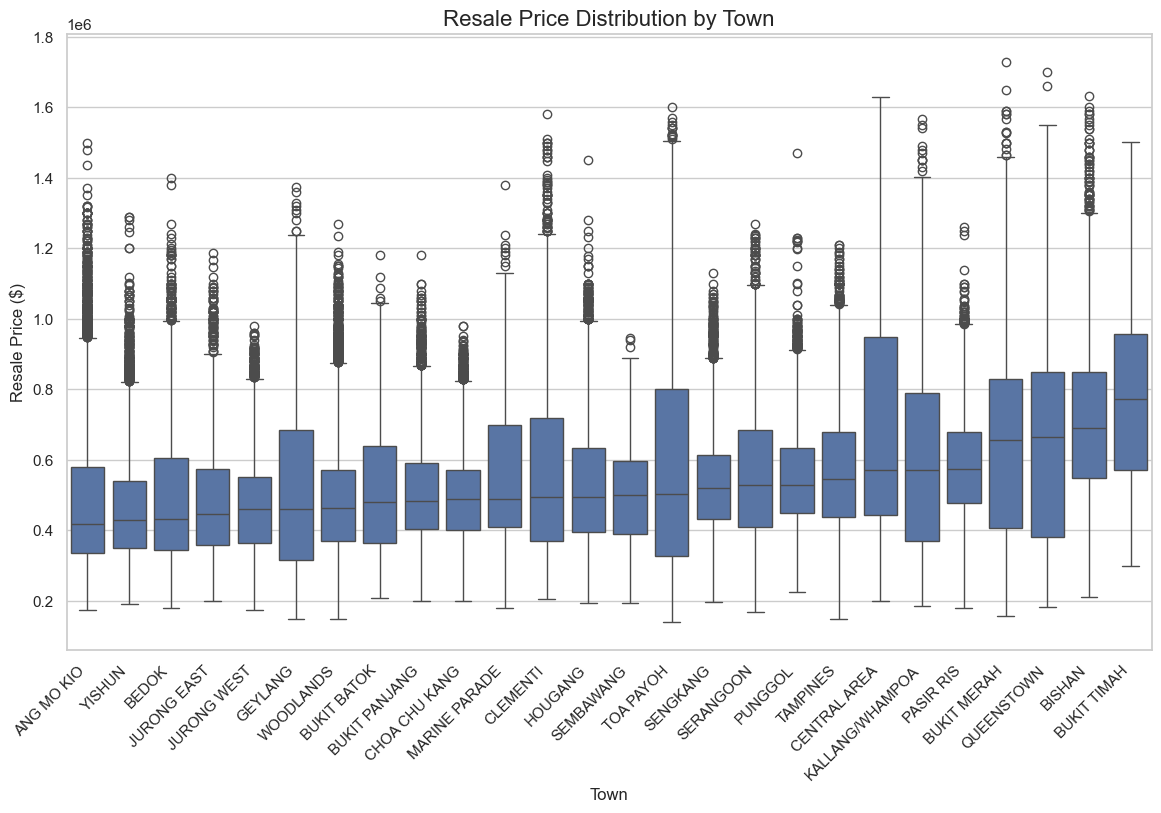

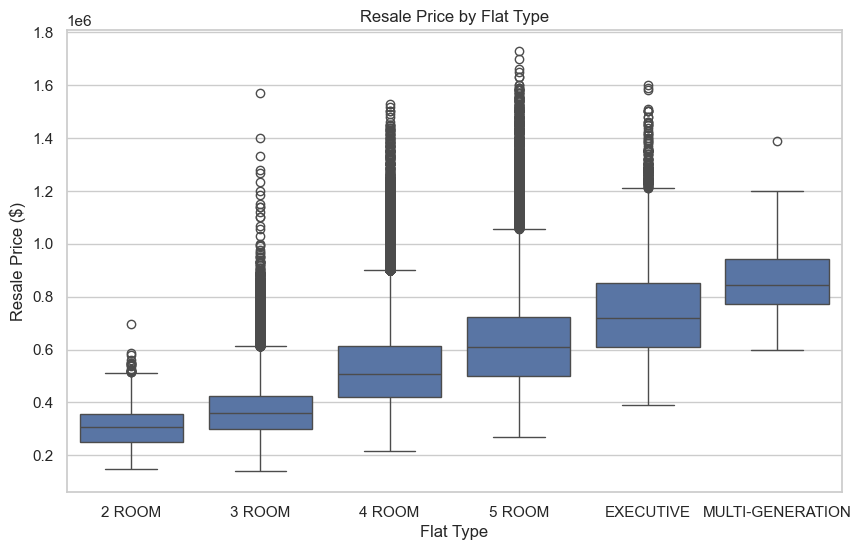

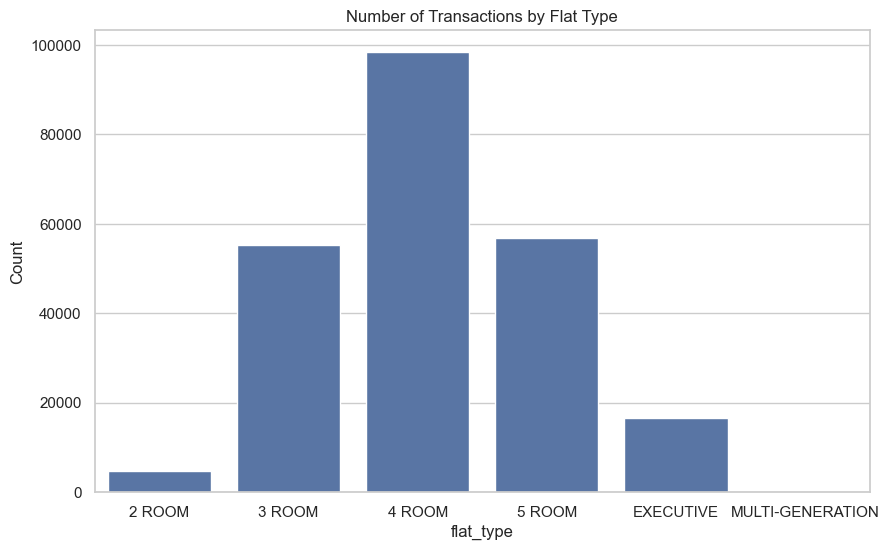

In [11]:
# Prices across different Towns
plt.figure(figsize=(14, 8))
# Sorting towns by median price makes the graph much easier to read
sorted_towns = df.groupby('town')['resale_price'].median().sort_values().index
sns.boxplot(x='town', y='resale_price', data=df, order=sorted_towns)
plt.title('Resale Price Distribution by Town', fontsize=16)
plt.xlabel('Town')
plt.ylabel('Resale Price ($)')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.show()

# Prices across different Flat Types
plt.figure(figsize=(10, 6))
sns.boxplot(x='flat_type', y='resale_price', data=df, 
            order=['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION'])
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Resale Price ($)')
plt.show()

# Count of transactions per Flat Type (Bar Chart)
plt.figure(figsize=(10, 6))
sns.countplot(x='flat_type', data=df, 
              order=['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION'])
plt.title('Number of Transactions by Flat Type')
plt.ylabel('Count')
plt.show()


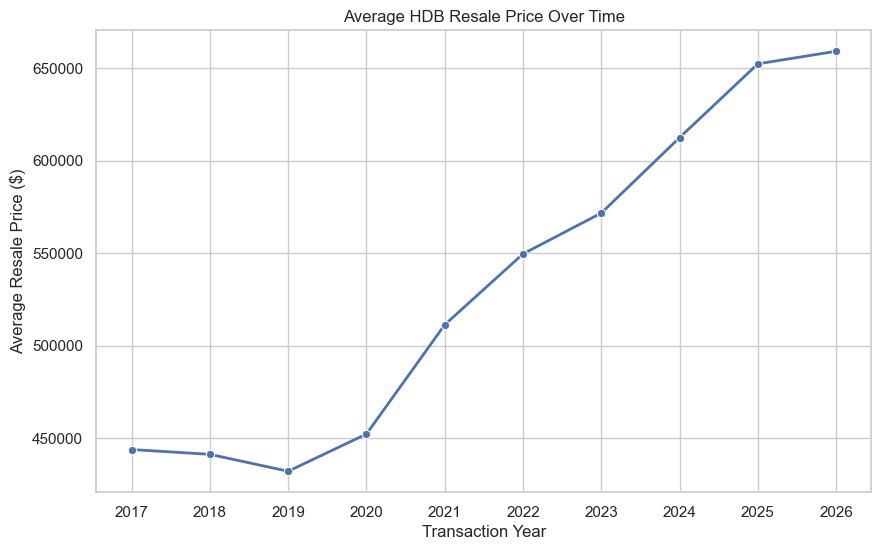

In [12]:
# Average price over the years
plt.figure(figsize=(10, 6))
# Calculate the mean price per year
yearly_prices = df.groupby('transaction_year')['resale_price'].mean().reset_index()

sns.lineplot(x='transaction_year', y='resale_price', data=yearly_prices, marker='o', linewidth=2)
plt.title('Average HDB Resale Price Over Time')
plt.xlabel('Transaction Year')
plt.ylabel('Average Resale Price ($)')
plt.xticks(yearly_prices['transaction_year']) # Ensure all years show on the axis
plt.show()
